# University of Wyoming and UFS-Chem: Read Paired Data and Create Plots

Our first example will demonstrate the basics available in MELODIES MONET to compare the UFS-Chem model results against University of Wyoming sonde observations (https://weather.uwyo.edu/upperair/sounding.shtml) for dewpoint, relative humidity, wind speed, wind direction, potential temperature, and specific humidity.

This example reads in the University of Wyoming paired data created by the previous example titled "Example for Pairing University of Wyoming data with UFS-Chem". This includes analysis over a day and a sampling of 2s.

First, we import the melodies_monet.driver module.

In [1]:
from melodies_monet import driver

## Analysis driver class

Now, lets create an instance of the analysis driver class, melodies_monet.driver.analysis. It consists of these main parts:

* model instances

* observation instances

* a paired instance of both

In [2]:
an = driver.analysis()

Initially, most of our analysis object’s attributes are set to None, though some have meaningful defaults:

In [3]:
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control file

We set the YAML control file and begin by reading the file.

In [4]:
control_fn='control_read_looped_aircraft_UWY_UFS_CHEM.yaml'
an.control=control_fn
an.read_control() 
an.control_dict  

{'analysis': {'start_time': '2023-08-01 00:00:00',
  'end_time': '2023-08-02-00:00:00',
  'output_dir': './output/uwy_ufschem',
  'debug': True,
  'read': {'paired': {'method': 'netcdf',
    'filenames': {'uwy_ufschem': ['0801_12Z_72632_uwy_ufschem.nc4']}}}},
 'model': {'ufschem': {'files': 'example:ufschem:2023-08-01',
   'mod_type': 'ufschem',
   'radius_of_influence': 100000,
   'extra_calc': {'dewpoint': {'specific_hum': 'spfh',
     'pres_calc': 'pressure_model'},
    'rel_hum': {'specific_hum': 'spfh',
     'pres_calc': 'pressure_model',
     'temp_calc': 'temperature_k'},
    'windspeed': {'u_comp': 'ugrd', 'v_comp': 'vgrd'},
    'winddir': {'u_comp': 'ugrd', 'v_comp': 'vgrd'},
    'ptemp_mod': {'pres_calc': 'pressure_model',
     'temp_calc': 'temperature_k'}},
   'mapping': {'uwy': {'temperature_k': 'temperature_C',
     'dewpoint': 'dpt_obs',
     'rel_hum': 'relh_obs',
     'windspeed': 'windspeed_obs',
     'winddir': 'wdir_obs',
     'ptemp_mod': 'ptemp_obs'}},
   'variabl

Now, some of our analysis object’s attributes are populated:

In [5]:
an

analysis(
    control='control_read_looped_aircraft_UWY_UFS_CHEM.yaml',
    control_dict=...,
    models={},
    obs={},
    paired={},
    start_time=Timestamp('2023-08-01 00:00:00'),
    end_time=Timestamp('2023-08-02 00:00:00'),
    time_intervals=None,
    download_maps=True,
    output_dir='./output/uwy_ufschem',
    output_dir_save='./output/uwy_ufschem',
    output_dir_read='./output/uwy_ufschem',
    debug=True,
    save=None,
    read={'paired': {'method': 'netcdf', 'filenames': {'uwy_ufschem': ['0801_12Z_72632_uwy_ufschem.nc4']}}},
    regrid=False,
)

## Load the model data

The driver will automatically loop through the “models” found in the model section of the YAML file and create an instance of melodies_monet.driver.model for each that includes the

* label

* mapping information

* file names (can be expressed using a glob expression)

* xarray object

In [6]:
an.open_models()

ufschem
example:ufschem:2023-08-01
**** Reading UFS-AQM or UFS-Chem model output...
Performing extra model calculations...
Calculating modeled Dewpoint...
Calculating modeled relative humidity...


/Users/rschwantes/Documents/MONET/version1.1/Met_updates/review/MELODIES-MONET/melodies_monet/util/metcalc.py:115: UserWarning: Saturation mixing ratio is undefined for some requested pressure/temperature combinations. Total pressure must be greater than the water vapor saturation pressure for liquid water to be in equilibrium.
  rlh = (metpy.calc.relative_humidity_from_specific_humidity(


Calculating modeled windspeed...
Calculating modeled wind direction...
Calculating modeled potential temperature...


Applying open_models() populates the models attribute.

In [7]:
an.models

{'ufschem': model(
     model='ufschem',
     is_global=False,
     radius_of_influence=100000,
     mod_kwargs={'var_list': ['spfh', 'ugrd', 'vgrd', 'lat', 'lon', 'phalf', 'tmp', 'pressfc', 'dpres', 'hgtsfc', 'delz']},
     file_str='example:ufschem:2023-08-01',
     label='ufschem',
     obj=...,
     extra_calc={'dewpoint': {'specific_hum': 'spfh', 'pres_calc': 'pressure_model'}, 'rel_hum': {'specific_hum': 'spfh', 'pres_calc': 'pressure_model', 'temp_calc': 'temperature_k'}, 'windspeed': {'u_comp': 'ugrd', 'v_comp': 'vgrd'}, 'winddir': {'u_comp': 'ugrd', 'v_comp': 'vgrd'}, 'ptemp_mod': {'pres_calc': 'pressure_model', 'temp_calc': 'temperature_k'}},
     mapping={'uwy': {'temperature_k': 'temperature_C', 'dewpoint': 'dpt_obs', 'rel_hum': 'relh_obs', 'windspeed': 'windspeed_obs', 'winddir': 'wdir_obs', 'ptemp_mod': 'ptemp_obs'}},
     variable_dict={'spfh': 'None', 'pressure_model': {'rename': 'pressure_model', 'unit_scale': 1, 'unit_scale_method': '*'}, 'temperature_k': 'None', 'ugr

We can access the underlying dataset with the obj attribute.

In [8]:
an.models['ufschem'].obj

<xarray.Dataset> Size: 8GB
Dimensions:         (time: 24, z: 64, y: 192, x: 384)
Coordinates:
    latitude        (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
    longitude       (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
  * time            (time) datetime64[ns] 192B 2023-08-01T01:00:00 ... 2023-0...
Dimensions without coordinates: z, y, x
Data variables: (12/15)
    spfh            (time, z, y, x) float32 453MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    ugrd            (time, z, y, x) float32 453MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    vgrd            (time, z, y, x) float32 453MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    temperature_k   (time, z, y, x) float32 453MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    surfpres_pa     (time, y, x) float32 7MB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    dp_pa           (time, z, y, x) float32 453MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    ...              ...
    alt_msl_m_full  (time, z, y, x) float32 453MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    dewpoint        (time, z, y, x) float64 906MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    rel_hum         (time, z, y, x) float64 906MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    windspeed       (time, z, y, x) float32 453MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    winddir         (time, z, y, x) float32 453MB 88.26 89.23 ... 49.98 48.84
    ptemp_mod       (time, z, y, x) float64 906MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
Attributes:
    ak:           [2.0000000e+01 6.4247000e+01 1.3779000e+02 2.2195800e+02 3....
    bk:           [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0....
    grid:         gaussian
    grid_id:      1
    hydrostatic:  non-hydrostatic
    im:           384
    jm:           192
    ncnsto:       139
    source:       FV3GFS
    history:      Tue Mar  3 14:52:03 2026: ncrcat 20230801_dynf001.nc 202308...
    NCO:          netCDF Operators version 5.0.7 (Homepage = http://nco.sf.ne...

## Load the observational data

As with the model data, the driver will loop through the “observations” found in the obs section of the YAML file and create an instance of melodies_monet.driver.observation for each.

In [9]:
an.open_obs()

Performing extra calculations for obs...
Calculating observed potential temperature...


In [10]:
an.obs

{'uwy': observation(
     obs='uwy',
     label='uwy',
     file='example:uwy-sonde:2023-08-01',
     obj=...,
     extra_calc={'ptemp_obs': {'temp_calc': 'temperature_C', 'pres_calc': 'pressure_obs'}},
     type='pt_src',
     sat_type=None,
     sat_method=None,
     data_proc=None,
     variable_dict={'temperature_C': {'unit_scale': 273.15, 'unit_scale_method': '+', 'ylabel_plot': 'Temperature (K)', 'xlabel_plot': 'Temperature (K)', 'nan_value': -1}, 'ptemp_obs': {'ylabel_plot': 'Potential Temperature (K)', 'xlabel_plot': 'Potential Temperature (K)'}, 'pressure_obs': {'rename': 'pressure_obs', 'unit_scale': 100, 'unit_scale_method': '*', 'ylabel_plot': 'Pressure (Pa)', 'xlabel_plot': 'Pressure (Pa)', 'nan_value': -1}, 'dpt_obs': {'rename': 'dpt_obs', 'unit_scale': 273.15, 'unit_scale_method': '+', 'ylabel_plot': 'Dewpoint (K)', 'xlabel_plot': 'Dewpoint (K)', 'nan_value': -1}, 'relh_obs': {'rename': 'relh_obs', 'unit_scale': 1, 'unit_scale_method': '*', 'ylabel_plot': 'Relative Humid

In [11]:
an.obs['uwy'].obj

<xarray.Dataset> Size: 405kB
Dimensions:                  (time: 3619)
Coordinates:
  * time                     (time) datetime64[ns] 29kB 2023-08-01T11:05:36 ....
Data variables: (12/13)
    longitude                (time) float64 29kB -83.47 -83.47 ... nan -83.13
    latitude                 (time) float64 29kB 42.7 42.7 42.7 ... nan 41.93
    pressure_obs             (time) float64 29kB 9.836e+04 9.824e+04 ... 520.0
    geopotential height_m    (time) float64 29kB 332.0 343.0 ... nan 3.597e+04
    temperature_C            (time) float64 29kB 286.9 288.8 290.0 ... nan 239.6
    dpt_obs                  (time) float64 29kB 286.0 286.7 286.1 ... nan 196.0
    ...                       ...
    relh_obs                 (time) float64 29kB 95.0 87.5 77.5 ... nan nan 0.0
    humidity wrt ice_%       (time) float64 29kB 95.0 87.5 77.5 ... nan nan 1.0
    mixing ratio_g/kg        (time) float64 29kB 9.58 9.98 9.62 ... nan nan 0.2
    wdir_obs                 (time) float64 29kB 66.5 129.0 129.0 ... nan 109.0
    windspeed_obs            (time) float64 29kB 1.25 2.9 3.25 ... nan nan 26.9
    ptemp_obs                (time) float64 29kB 288.3 290.3 ... nan 1.077e+03

## Read in the Paired Output Netcdf File

We read in the AEROMMA and UFS-AQM paired data created by the scripts here on Hera (/scratch1/BMC/rcm2/rhs/monet_example/AEROMMA/submit_jobs). This includes analysis over 4 flights and 2 days with a resampling of 30 s.

In [12]:
an.read_analysis()

Reading: ./output/uwy_ufschem/0801_12Z_72632_uwy_ufschem.nc4


In [13]:
an.paired
df = an.paired['uwy_ufschem'].obj.to_dataframe().reset_index()
#print(df)
#print(df.columns)
#print(len(df))

## Plot

The plotting() routine produces plots.

Using vertprofile_bins from YAML range: {'start': 0, 'stop': 100001, 'step': 5000}
Using vertprofile_bins from YAML range: {'start': 0, 'stop': 100001, 'step': 5000}
Using vertprofile_bins from YAML range: {'start': 0, 'stop': 100001, 'step': 5000}
Using vertprofile_bins from YAML range: {'start': 0, 'stop': 100001, 'step': 5000}
Using vertprofile_bins from YAML range: {'start': 0, 'stop': 100001, 'step': 5000}
Using vertprofile_bins from YAML range: {'start': 0, 'stop': 100001, 'step': 5000}


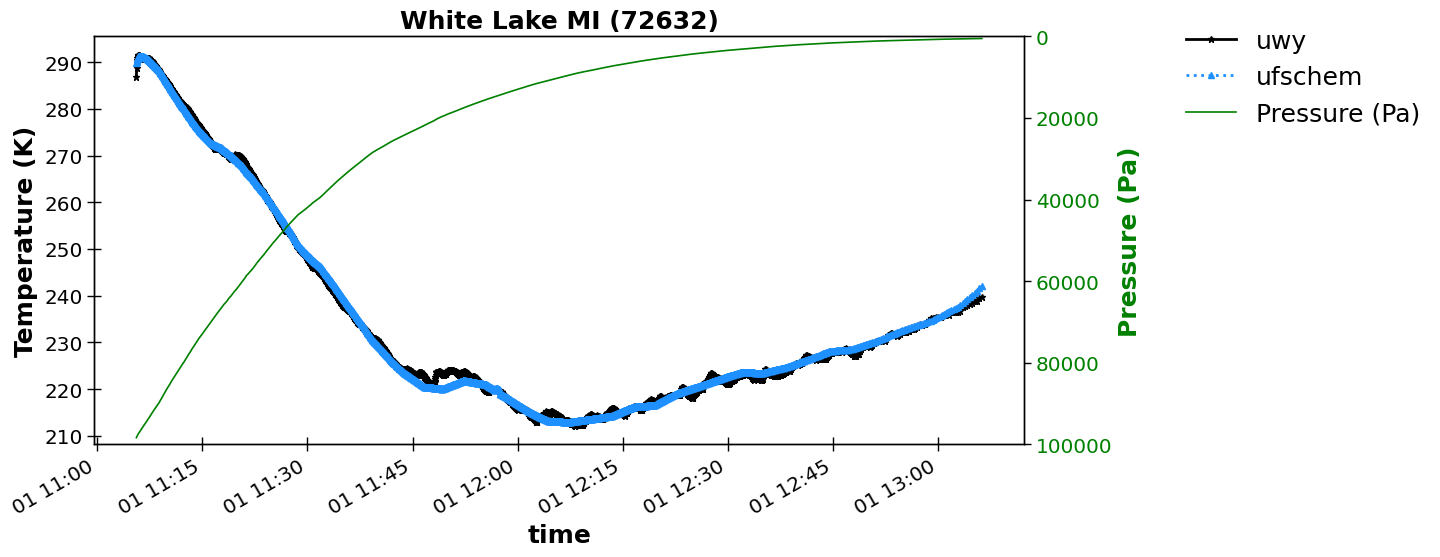

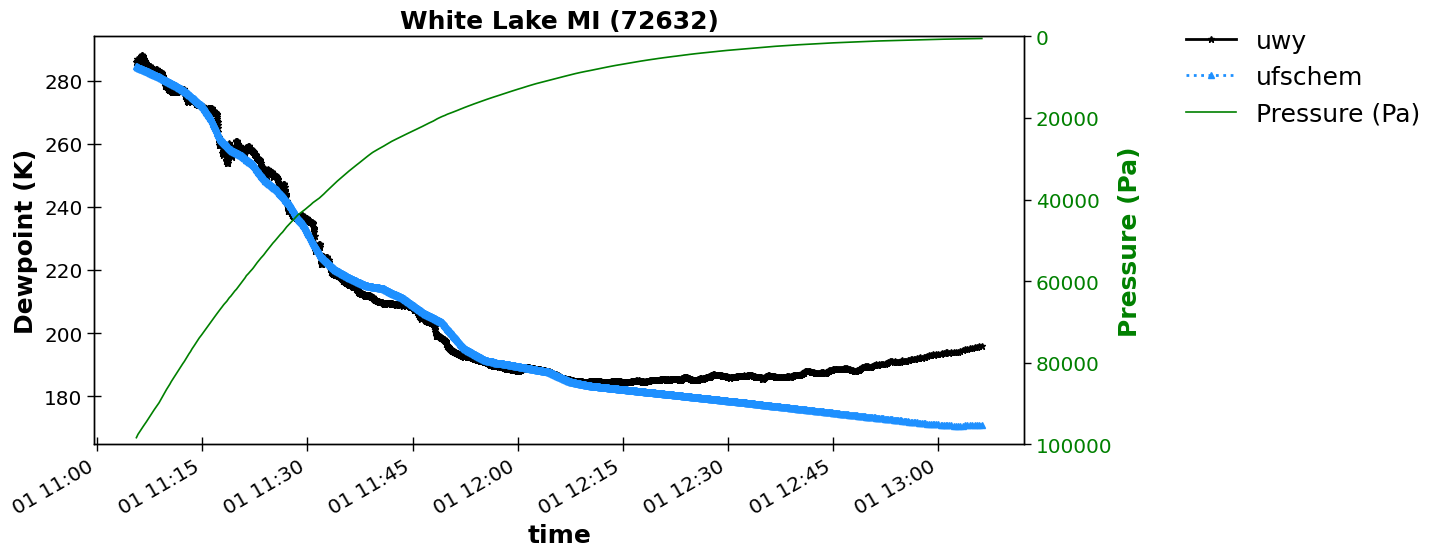

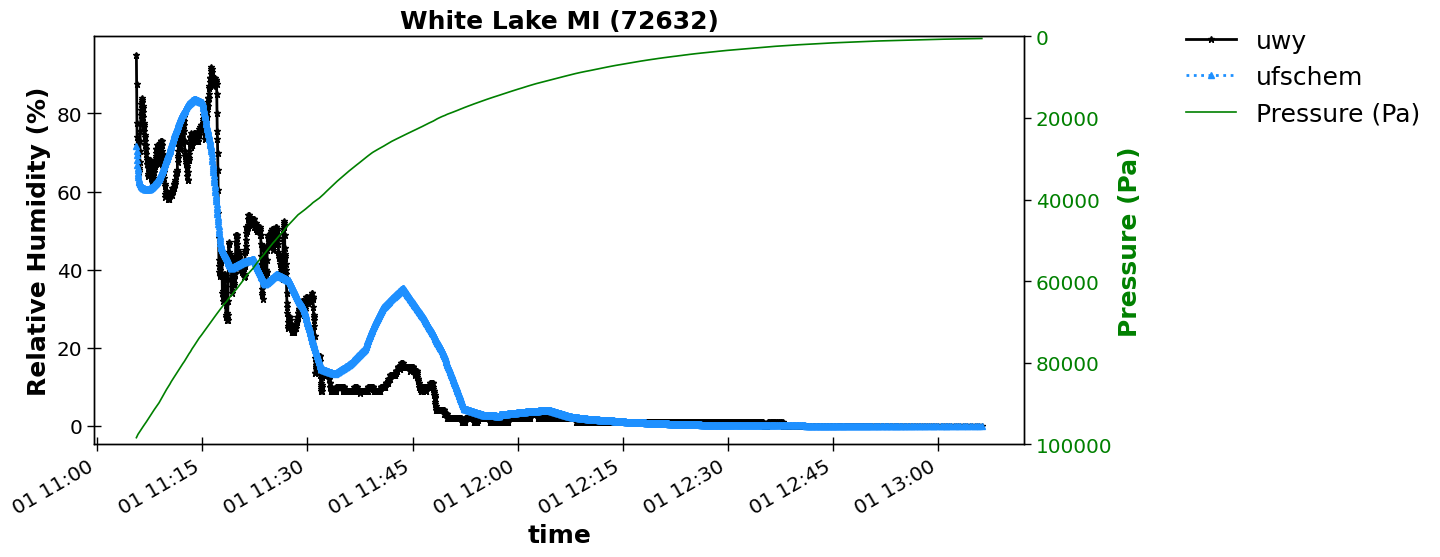

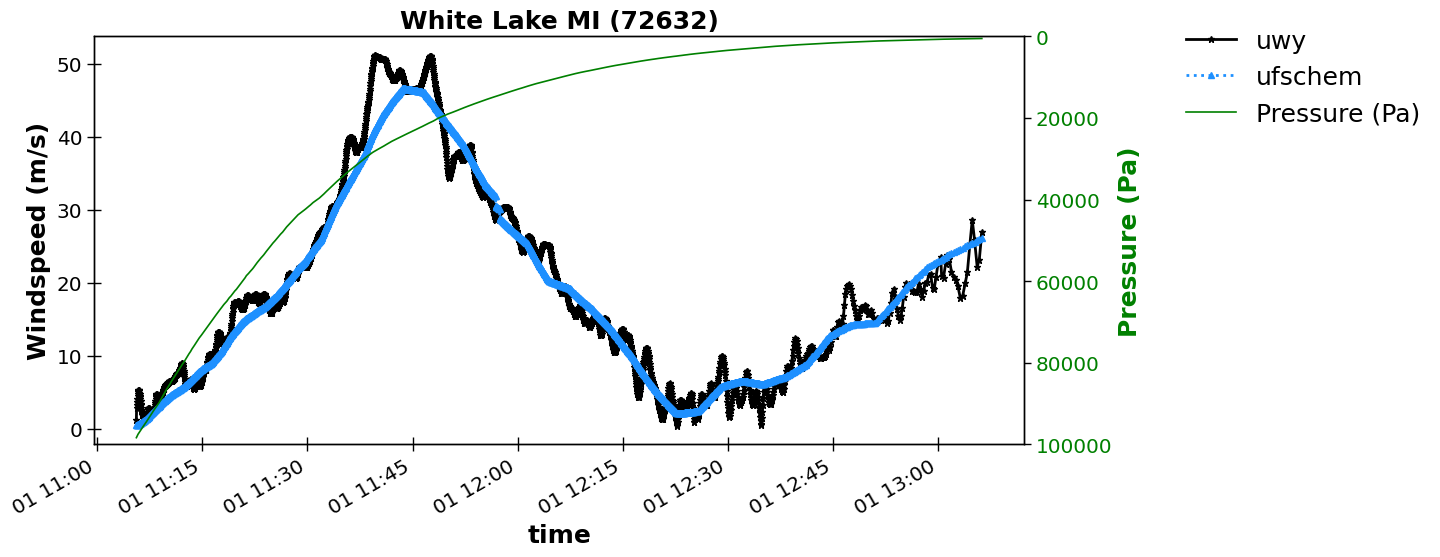

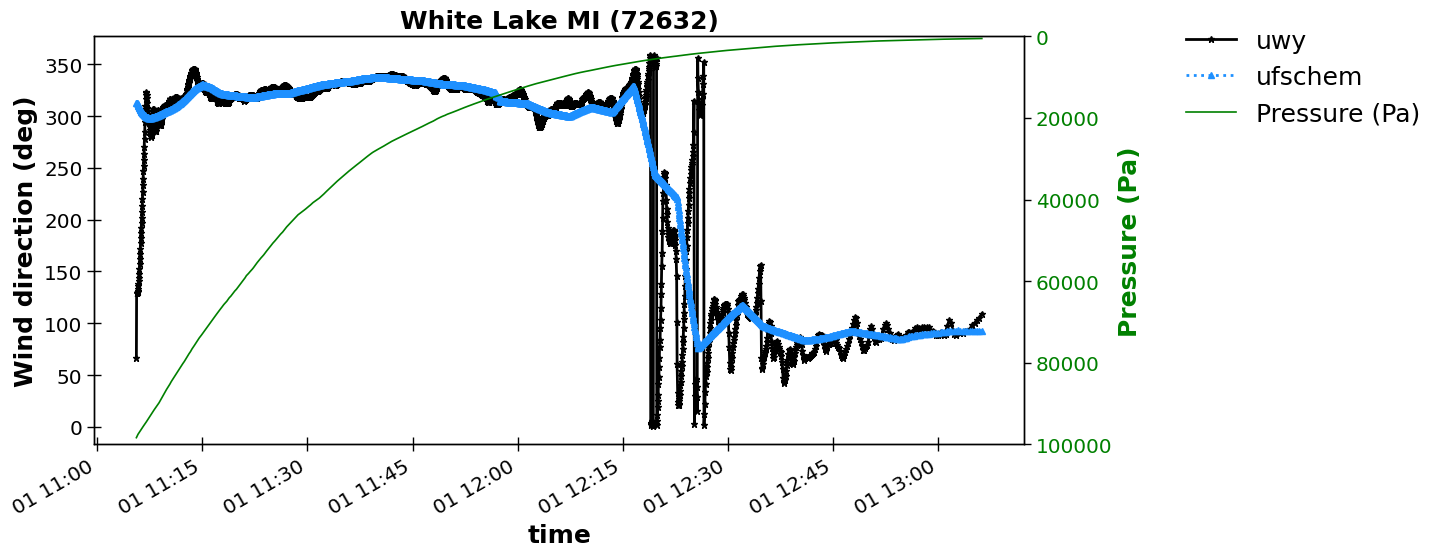

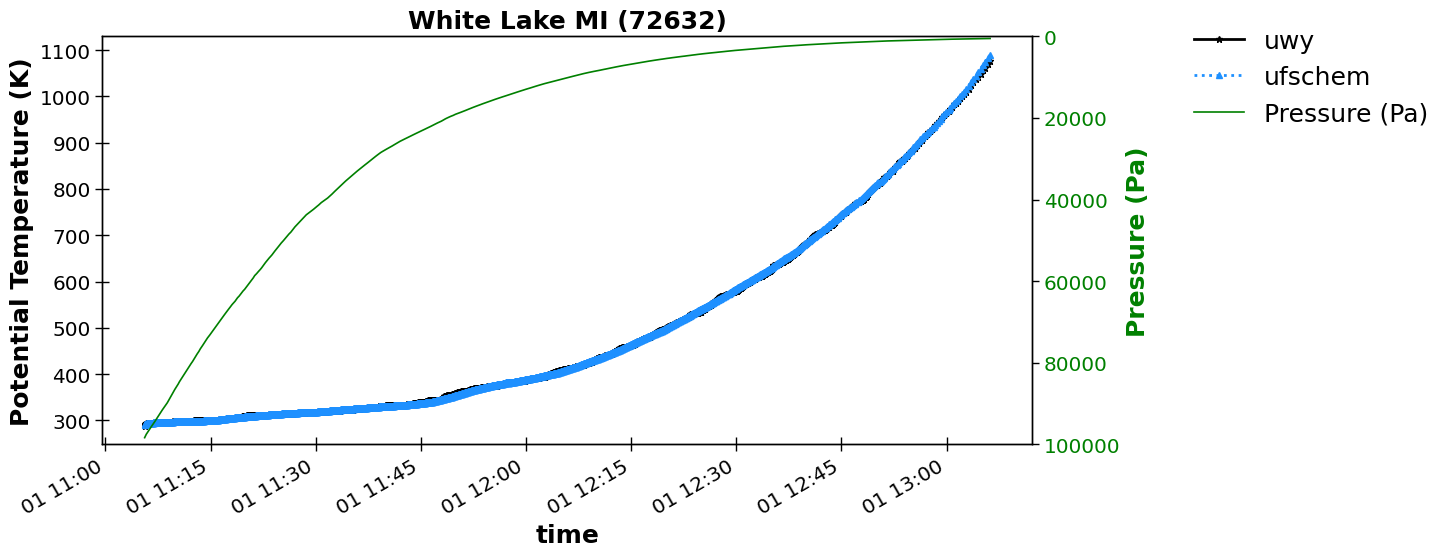

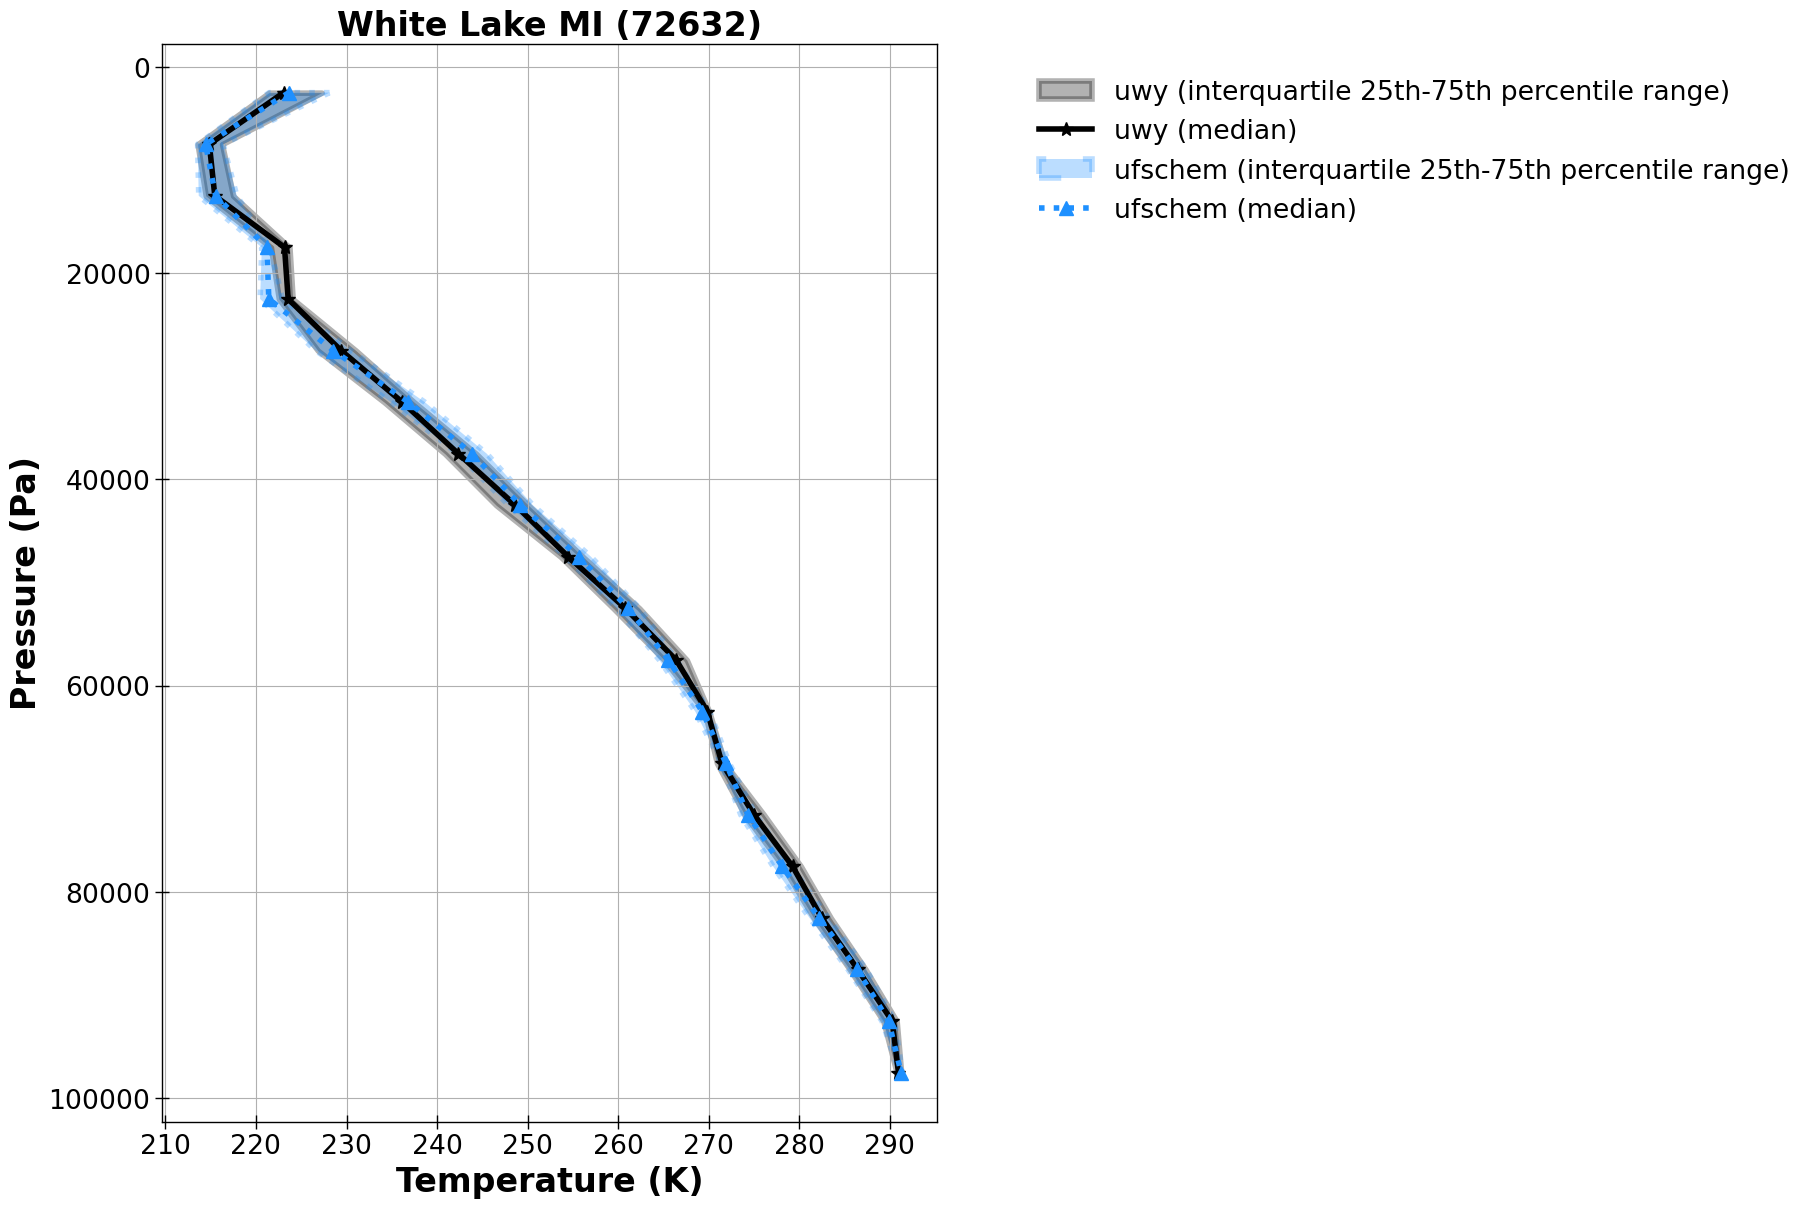

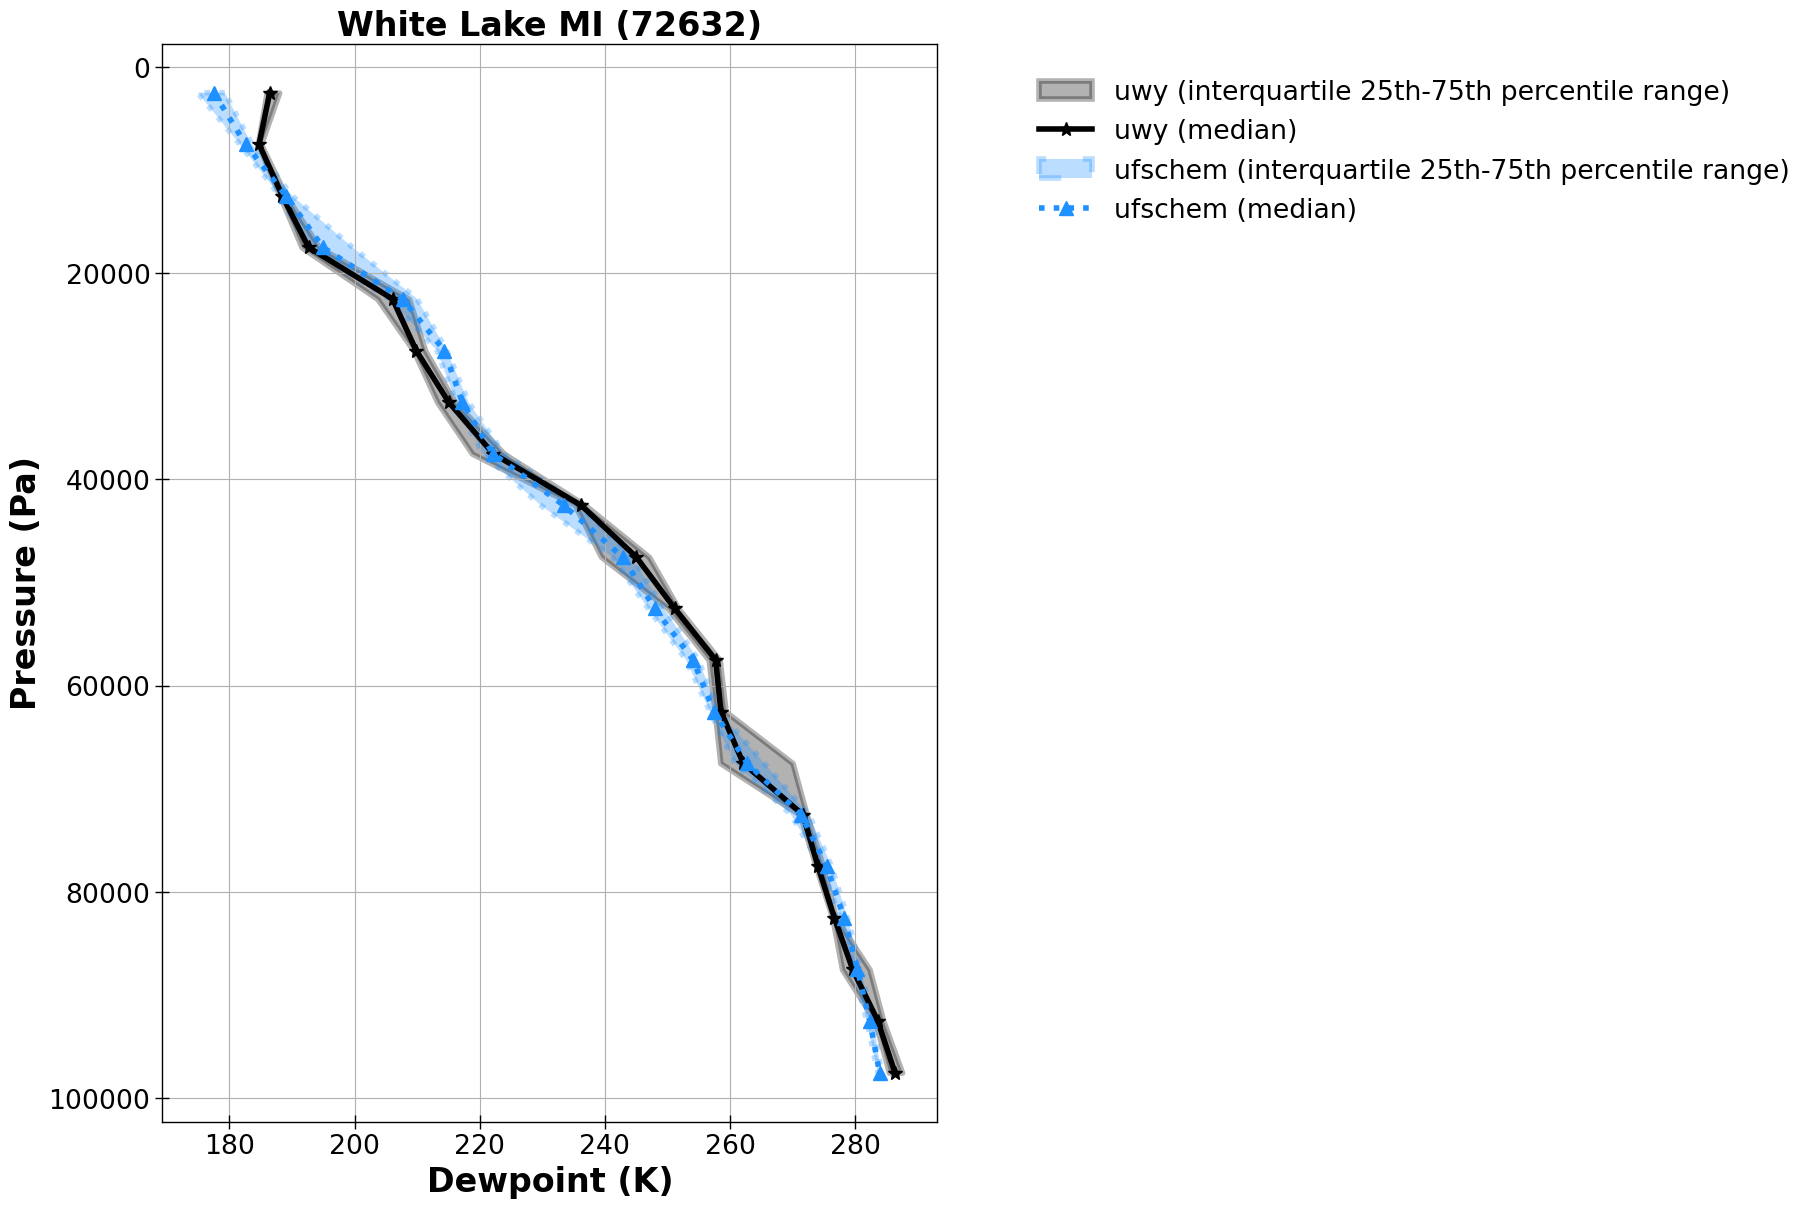

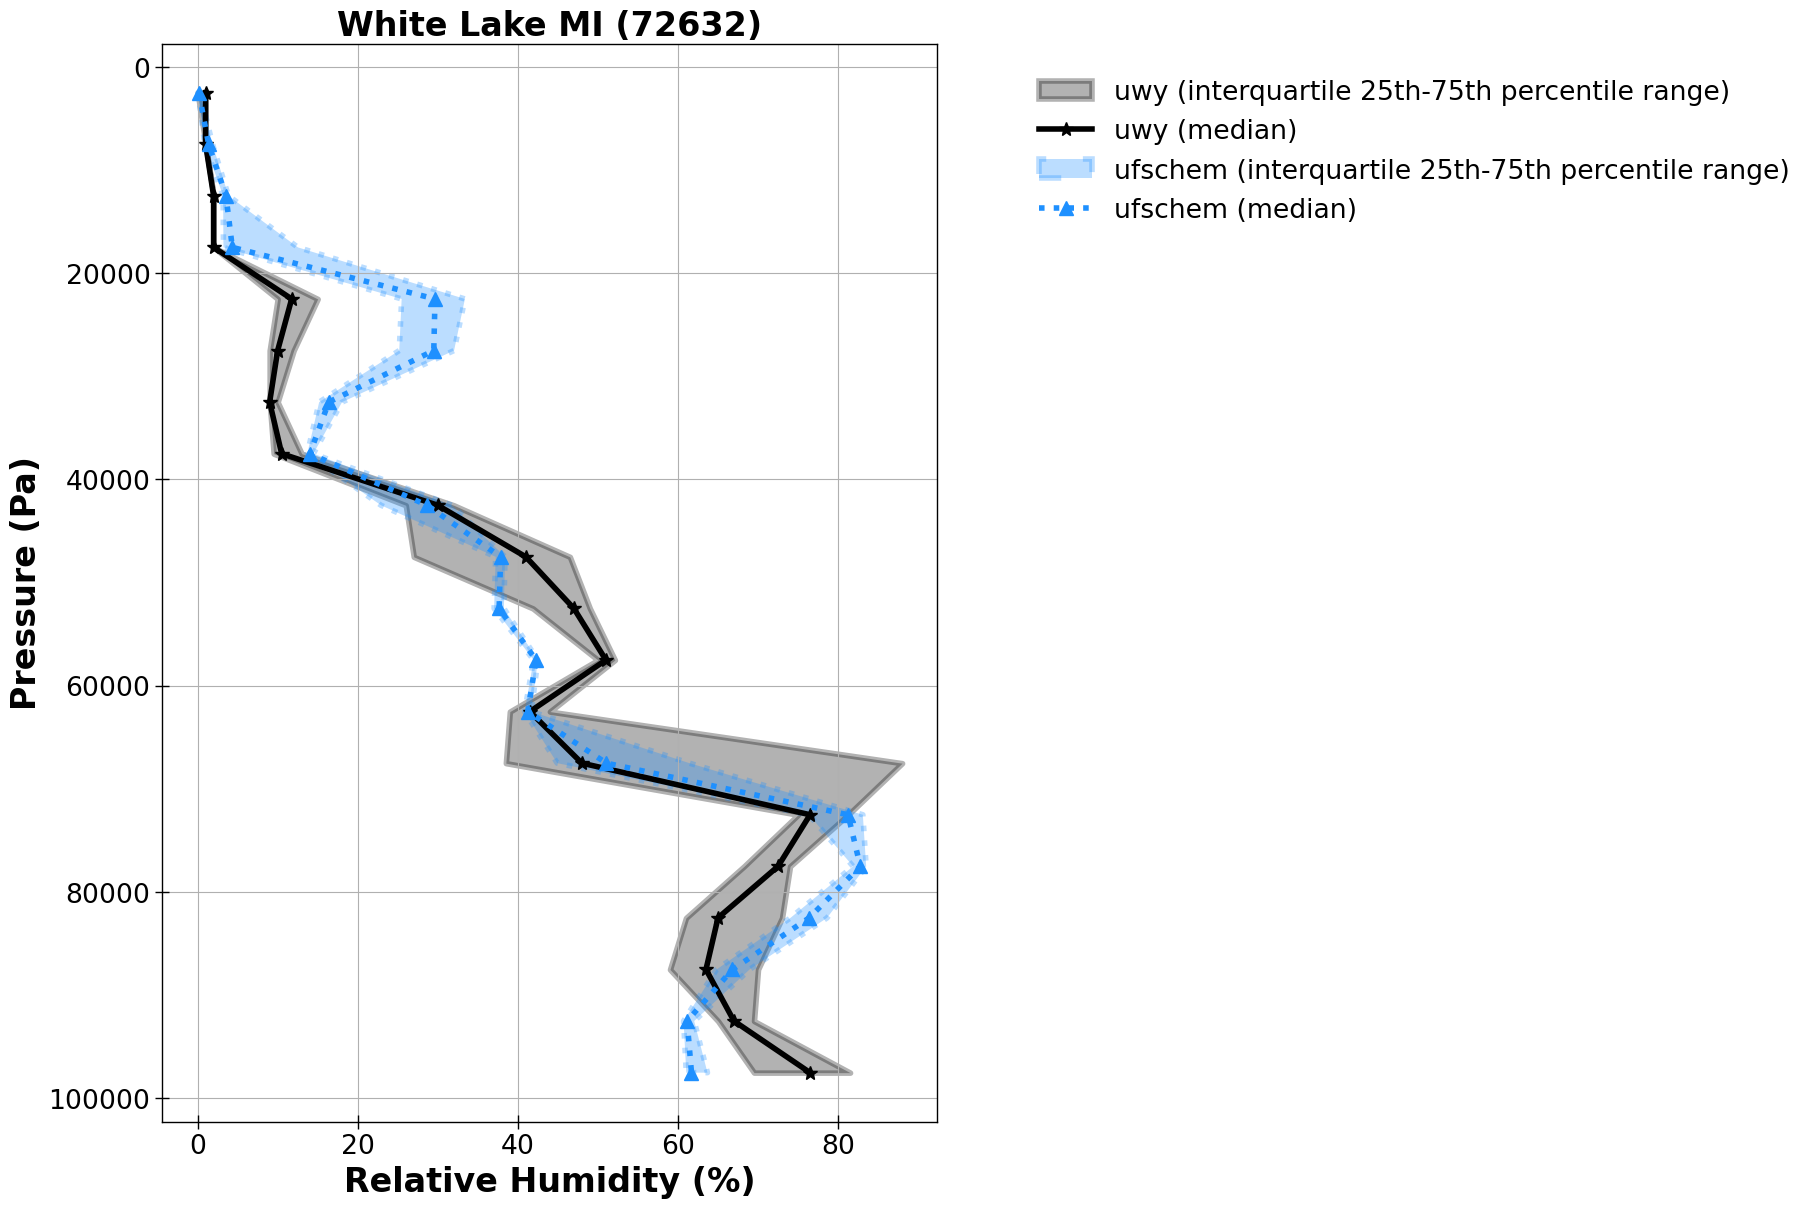

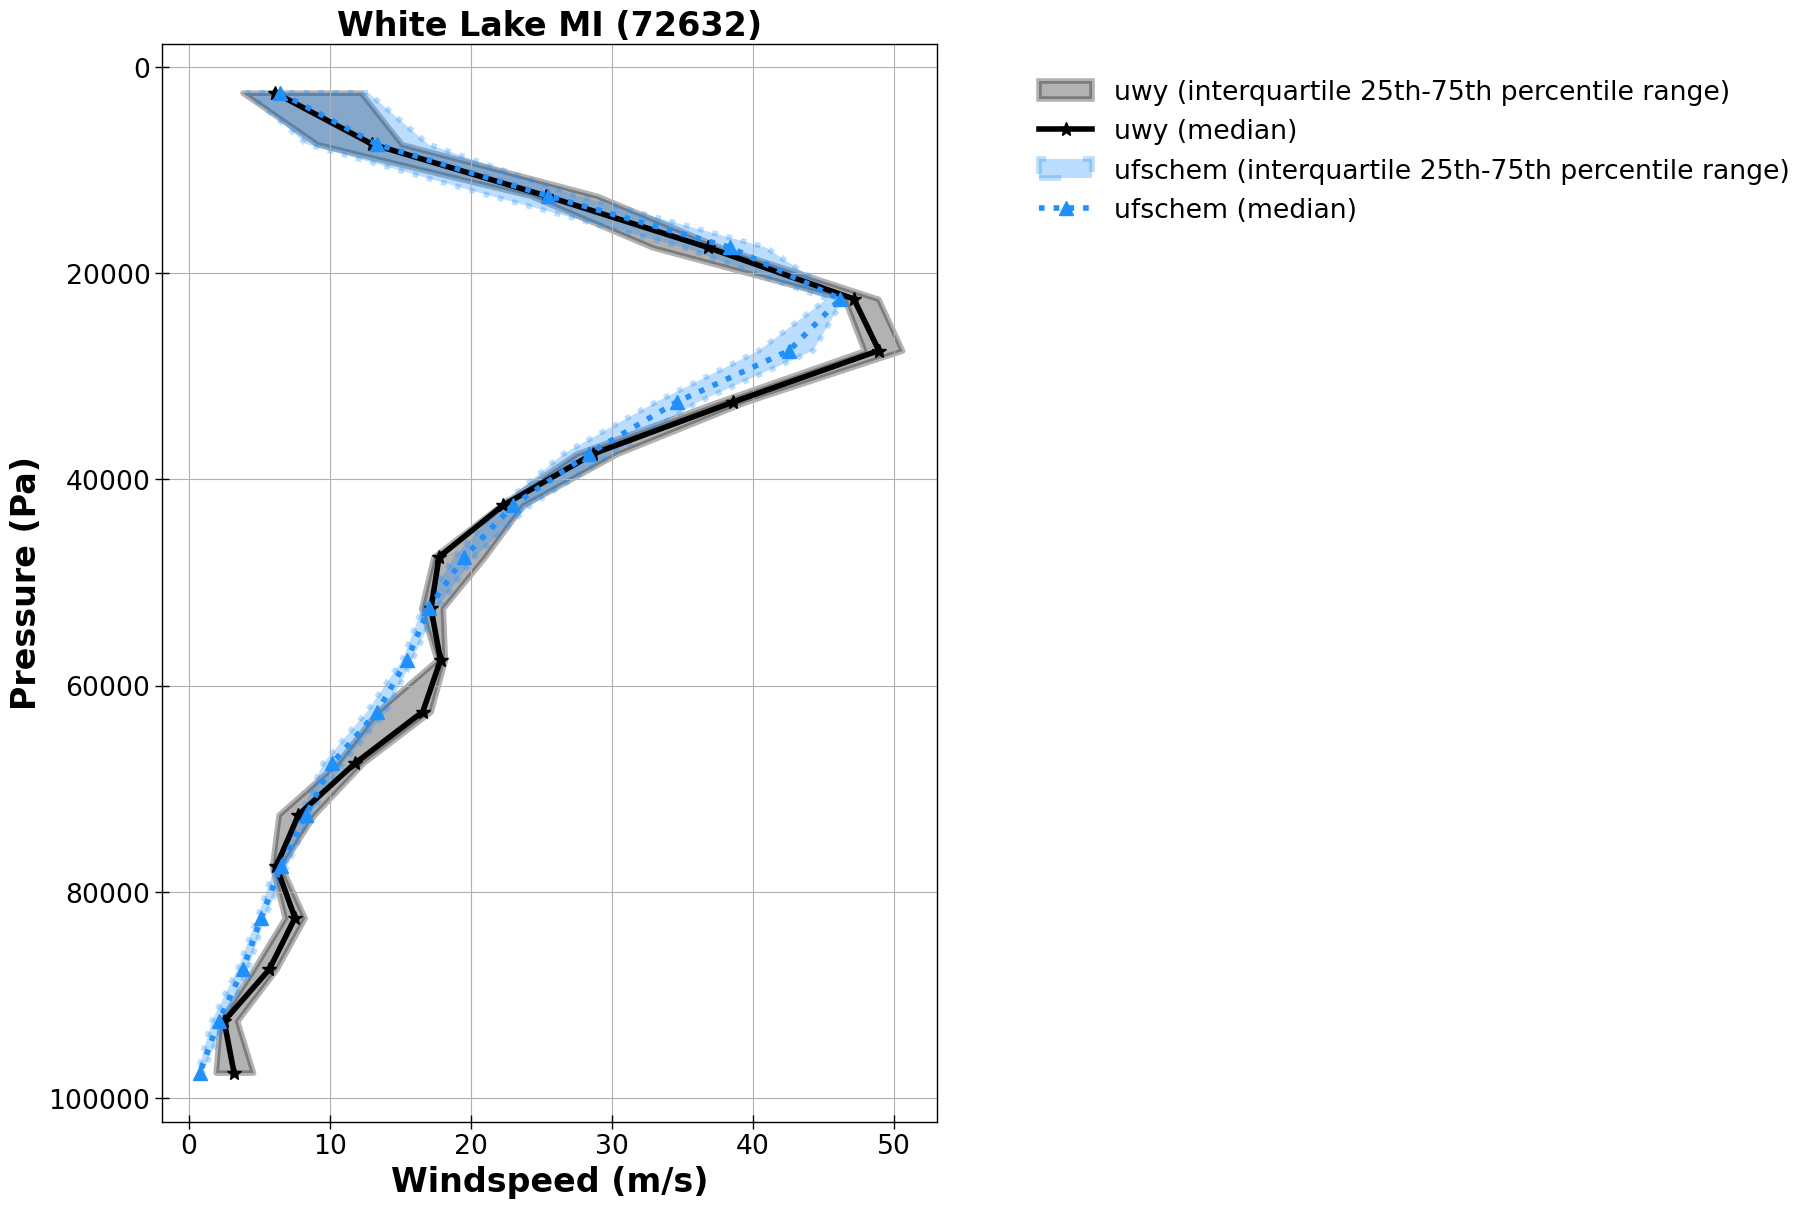

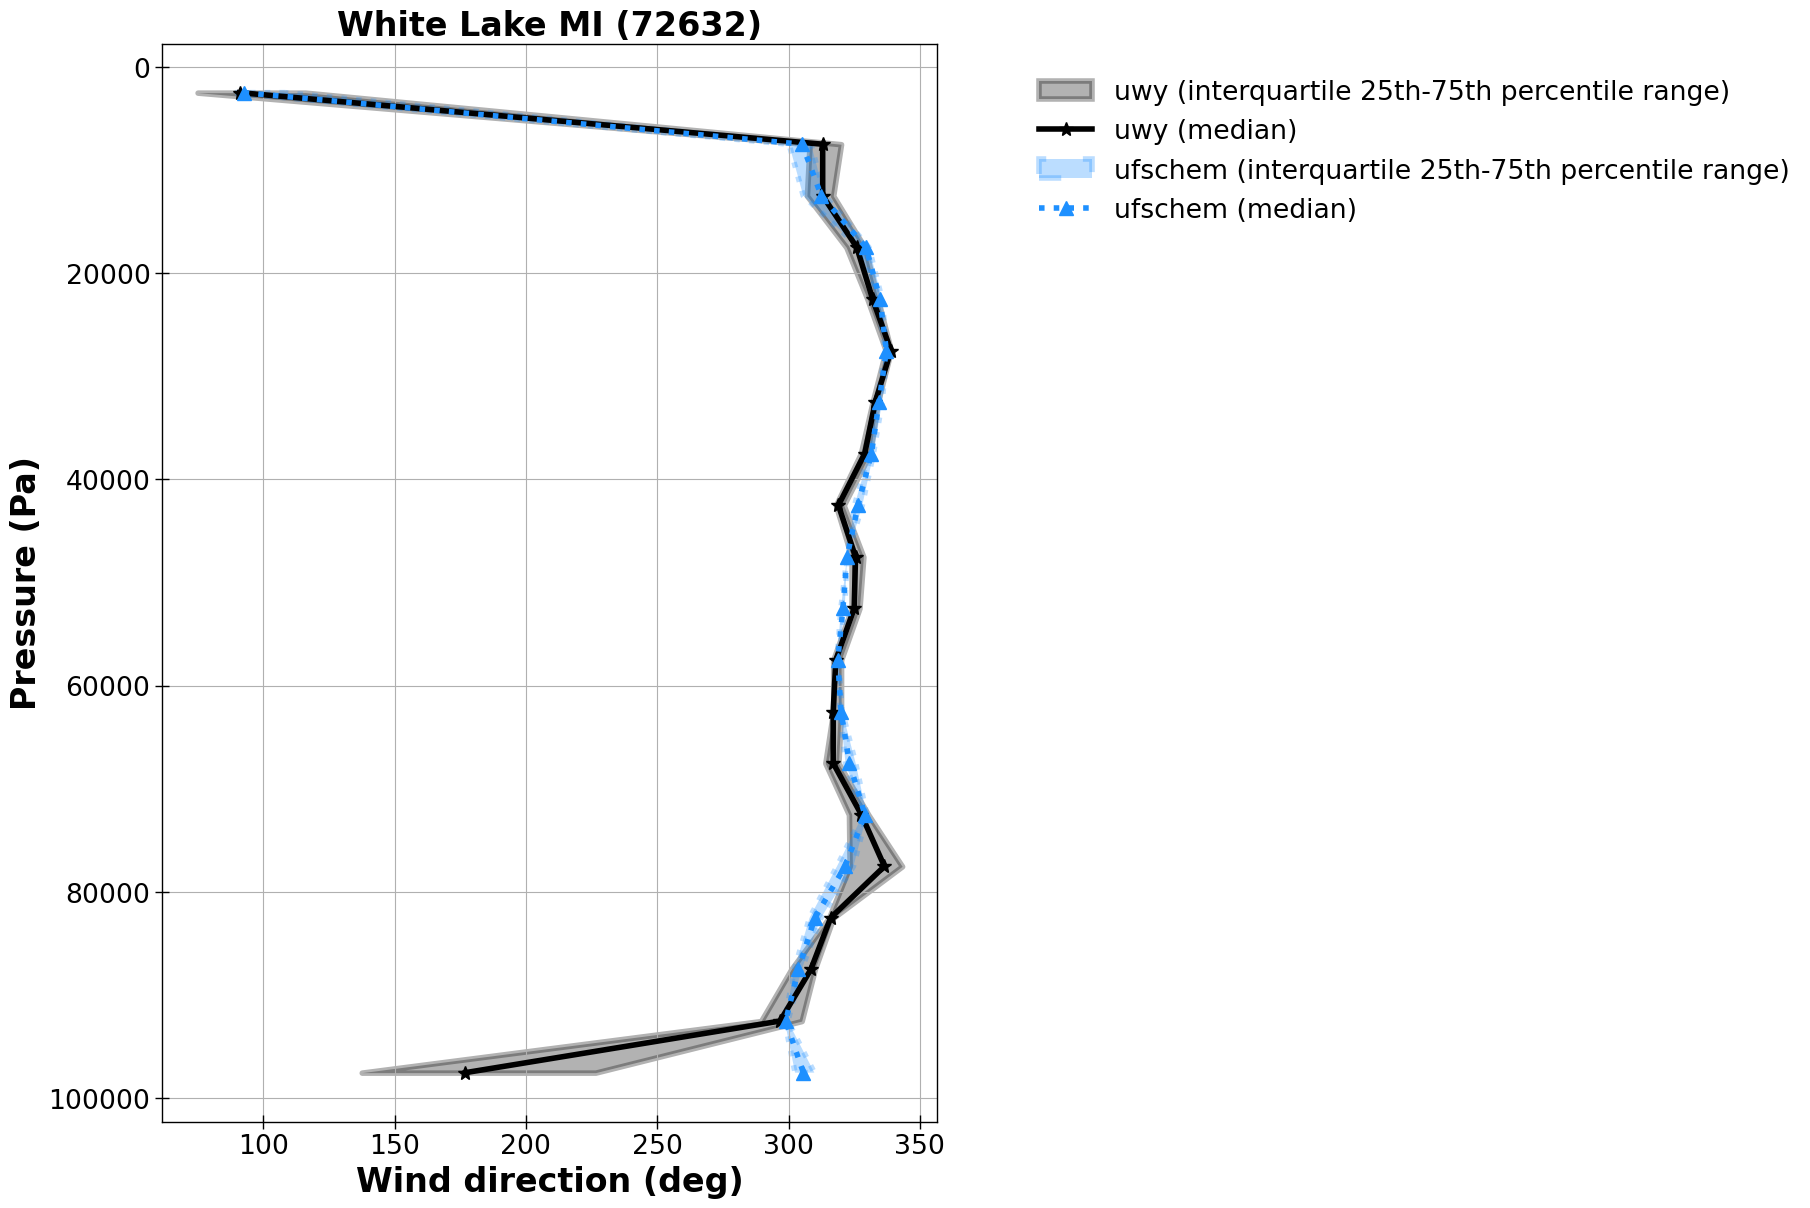

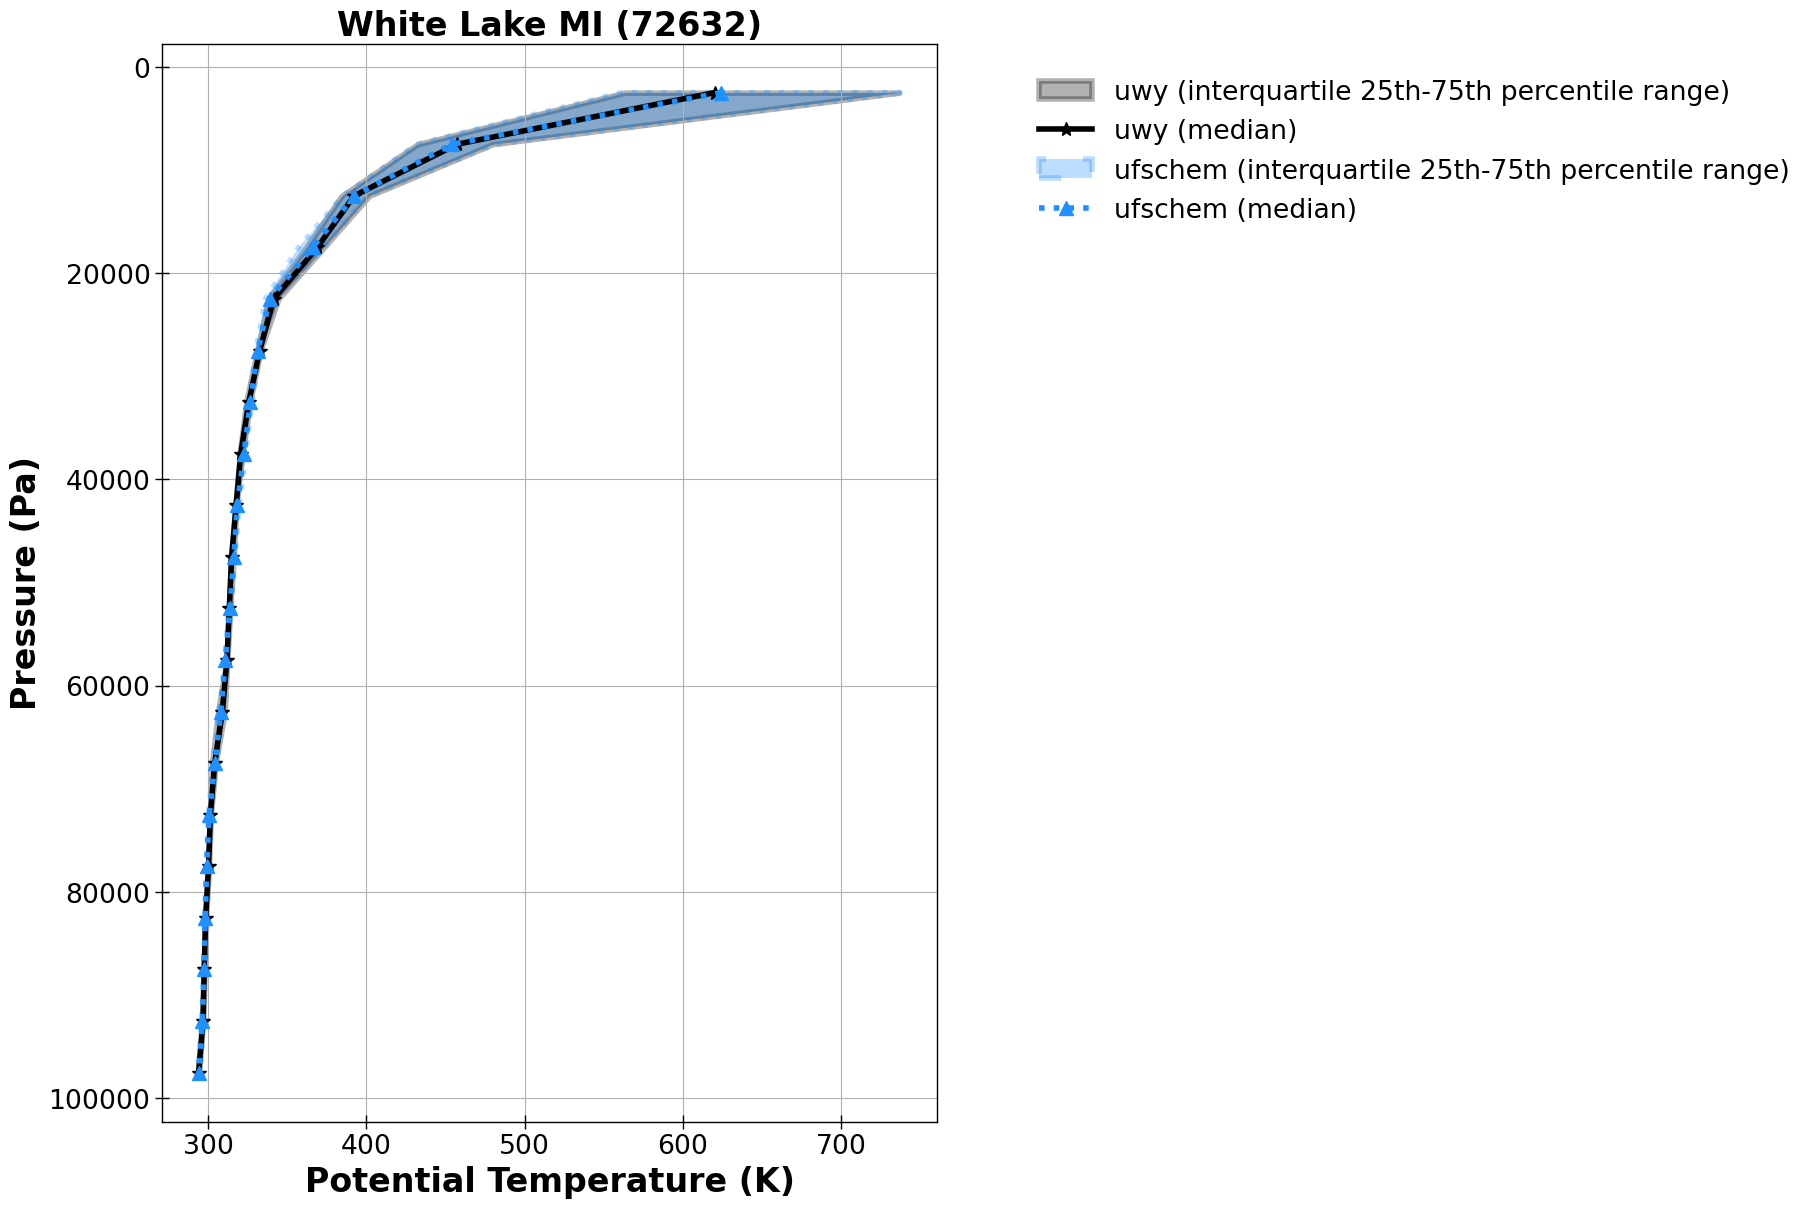

In [14]:
an.plotting()